# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('drive/MyDrive/Date_Analysis/data/credit_risk_dataset.csv')

In [4]:
print(f'У датасеті {df.shape[0]} рядків та {df.shape[1]} колонок.')

У датасеті 32581 рядків та 12 колонок.


In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
loan_dist = df['loan_status'].value_counts()
loan_perc = df['loan_status'].value_counts(normalize=True) * 100

loan_perc

,proportion
loan_status,
0,78.183604
1,21.816396


Маємо задачу незбалансованої класифікації (78% vs 22%).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [8]:
# Обчислимо відсоток пропущених значень в колонках

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_percent[missing_percent > 0]

,0
person_emp_length,2.747000
loan_int_rate,9.563856


Бачимо відсутні значення в двох колонках: person_emp_length та loan_int_rate. Заповнимо пропуски в цих колонках медіанами.

In [9]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

Проаналізуємо розподіл числових змінних

In [10]:
# Базова статистика по числовим змінним:

df_stat = df.select_dtypes('number').describe().round(2)

df_stat

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [11]:
# Знайдемо викиди в колонці person_income

Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
print(f'Кількість викидів: {len(outliers)}')

Кількість викидів: 1484


In [12]:
# Видаляємо викиди знайдені в колонці person_income:

df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()
print(f'Розмір оновленого датасету без викидів: {df_clean.shape}')

Розмір оновленого датасету без викидів: (31097, 12)


In [13]:
# Проаналізуємо статус кредиту vs річний дохід позичальників

fig = px.box(
    df_clean,
    x='loan_status',
    y='person_income',
    title='Cтатус кредиту vs річний дохід позичальників',
    color='loan_status',
    color_discrete_map={0:'#89dcb3', 1:'#e59c99'}
)

fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Статус кредиту',
                yaxis_title='Сума доходу')

fig.show()

Позичальники з вищим доходом частіше гасять кредит.

In [14]:
# Проаналізуємо статус кредиту vs сума кредиту

fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
    title='Cтатус кредиту vs сума кредиту',
    color='loan_status',
    color_discrete_map={0:'#89dcb3', 1:'#e59c99'}
)

fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Статус кредиту',
                yaxis_title='Сума кредиту')

fig.show()

З графіку бачимо, що у більших сумах кредиту більший шанс, що позичальник його не погасить.

Проаналізуємо категоріальні змінні

In [15]:
# Проаналізуємо частоту зустрічань різних значень в категоріальних змінних:

cat_columns = ['person_home_ownership', 'loan_intent',
              'loan_grade', 'cb_person_default_on_file']

print('Частота зустрічань різних значень у відсотковому співвідношенні:')

for col in cat_columns:
    print('=' * 30)
    print(df[col].value_counts(normalize=True) * 100)
    print('=' * 30)

Частота зустрічань різних значень у відсотковому співвідношенні:
person_home_ownership
RENT        50.477272
MORTGAGE    41.263313
OWN          7.931003
OTHER        0.328412
Name: proportion, dtype: float64
loan_intent
EDUCATION            19.806022
MEDICAL              18.633559
VENTURE              17.553175
PERSONAL             16.945459
DEBTCONSOLIDATION    15.997053
HOMEIMPROVEMENT      11.064731
Name: proportion, dtype: float64
loan_grade
A    33.077561
B    32.076977
C    19.821368
D    11.129186
E     2.958780
F     0.739695
G     0.196434
Name: proportion, dtype: float64
cb_person_default_on_file
N    82.367024
Y    17.632976
Name: proportion, dtype: float64


In [16]:
# Статус кредиту за типом володіння житлом

home_loan_gr = df.groupby(['person_home_ownership','loan_status']).size().unstack()
home_loan_gr_perc = home_loan_gr.div(home_loan_gr.sum (axis=1), axis=0) * 100

fig = px.bar(
    home_loan_gr_perc.T,
    title='Статус кредиту за типом володіння житлом',
    barmode='group'
)

fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Статус кредиту',
                yaxis_title='Відсоток (%)')

fig.show()

Позичальники зі своїм  житлом найчастіше гасять кредит, а у позичальників з орендованим житлом більший ризик дефолту.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [17]:
# Матриця кореляцій:

cor_matrix = df_clean.select_dtypes('number').corr()

In [18]:
# Візуалізація кореляцій

fig = px.imshow(
    cor_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляційна матриця числових змінних',
    labels=dict(color="Кореляція")
)

fig.update_layout(height=700)
fig.show()

In [19]:
# Закодуємо категоріальні змінні використовуючи One-hot encoding

cat_cols = df_clean.select_dtypes('object').columns.tolist()

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

In [20]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [21]:
# Обираємо фінальний набір ознак

features = [col for col in df_encoded.columns if col != 'loan_status']


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [22]:
# Розділимо дані на X та y

X = df_encoded[features]
y = df_encoded['loan_status']

print (f'Кількість ознак: {X.shape[1]}')
print (f'Розмір вибірки: {X.shape[0]}')

Кількість ознак: 22
Розмір вибірки: 31097


In [23]:
# Розділимо дані на навчальну та тестову вибірки

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Перевіримо чи збереглася пропорція після розділення

print (f'Train: {X_train.shape[0]} позичальників')
print (f'Test: {X_test.shape[0]} позичальників')
print (f'Частка дефолту в train: {y_train.mean():.1f}')
print (f'Частка дефолту в test: {y_test.mean():.1f}')

Train: 24877 позичальників
Test: 6220 позичальників
Частка дефолту в train: 0.2
Частка дефолту в test: 0.2


In [24]:
# Застосовуємо масштабування

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Створюємо та навчаємо модель логістичної регресії

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Робимо прогнози на тренувальній та тестовій вибірках

In [26]:
# Прогнозуємо класи

y_pred = model.predict(X_test_scaled)

# Прогнозуємо ймовірності

y_pred_proba = model.predict_proba(X_test_scaled)

In [27]:
# Приклад прогнозів для перших п'яти позичальників

sample_pred = pd.DataFrame ({
    'Статус кредиту': y_test.values[:5],
    'Прогноз': y_pred[:5],
    'Ймовірність погашення': y_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту':  y_pred_proba[:5, 1].round(3)
})

sample_pred

,Статус кредиту,Прогноз,Ймовірність погашення,Ймовірність дефолту
0,0,0,0.969,0.031
1,0,0,0.986,0.014
2,0,0,0.965,0.035
3,0,0,0.965,0.035
4,0,1,0.165,0.835


Бачимо, що модель помилилась один раз, але доволі сильно.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


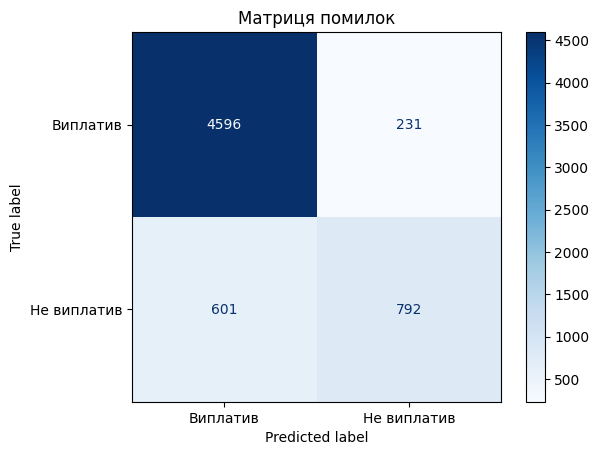

In [28]:
# Побудуємо матрицю помилок

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Виплатив', 'Не виплатив'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()


4596 разів - правильно передбачила, що виплатив;

792 рази - правильно передбачила, що НЕ виплатив;

231 раз - помилково передбачила, що НЕ виплатив;

601 раз - помилково передбачила, що виплатив.

In [29]:
# Обчислимо основні метрики

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('='*30)
print('МЕТРИКИ ЯКОСТІ МОДЕЛІ:')
print('='*30)
print(f'Accuracy (Точність):    {accuracy:.3f}')
print(f'Precision (Влучність):  {precision:.3f}')
print(f'Recall (Повнота):       {recall:.3f}')
print(f'F1-score:               {f1:.3f}')

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


In [35]:
# Побудуємо ROC-криву та обчислимо AUC

from sklearn.metrics import roc_curve, roc_auc_score

# Обчислюємо ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# Візуалізація

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500,
    template='plotly_white'
)
fig.show()

AUC = 0.874 - ми отримали хорошу модель

In [31]:
# Проаналізуємо важливість ознак:

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.318553,1.318553
17,loan_grade_D,0.812938,0.812938
3,loan_amnt,-0.546248,0.546248
18,loan_grade_E,0.477536,0.477536
8,person_home_ownership_OWN,-0.459162,0.459162
9,person_home_ownership_RENT,0.404043,0.404043
14,loan_intent_VENTURE,-0.400211,0.400211
10,loan_intent_EDUCATION,-0.326753,0.326753
20,loan_grade_G,0.309888,0.309888
19,loan_grade_F,0.269311,0.269311


Бачимо, що найбільше на цільову змінну впливають такі ознаки:
- відношення кредиту до доходу;
- позичальники з кредитним рейтингом D;
- сума кредиту (негативно).


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [37]:
# Проаналізуємо метрики якості при різних порогах:

thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення'
)

fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Поріг',
                yaxis_title='Значення метрики')

fig.show()

З графіку видно, що оптимальний поріг у нашому випадку - 0.36.

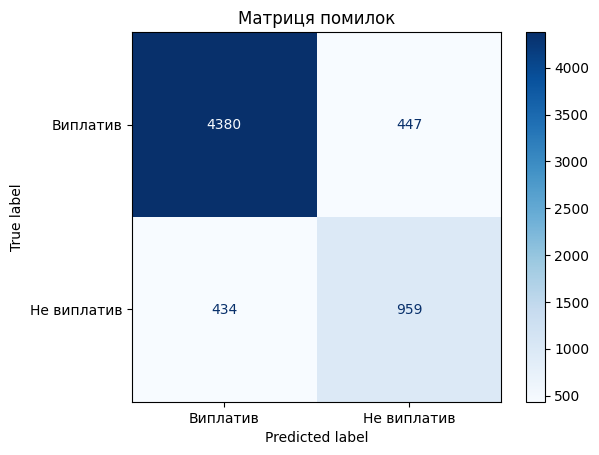

In [42]:
# Матриця помилок з порогом 0.36

y_pred_opt = y_pred_proba[:,1]>=0.36
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Виплатив', 'Не виплатив'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

З порогом 0.36 модель:

- 4380 рази - правильно передбачила, що виплатив;

- 959 рази - правильно передбачила, що НЕ виплатив;

- 447 разів - помилково передбачила, що НЕ виплатив;

- 434 рази - помилково передбачила, що виплатив.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [44]:
# Навчимо альтернативні моделі DecisionTreeClassifier та RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)

results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.866,0.774,0.569,0.656,0.874
1,Decision Tree,0.903,0.957,0.595,0.734,0.872
2,Random Forest,0.929,0.959,0.714,0.818,0.930


Об'єктивно, найкращий результат по метрикам якості дала модель Random Forest. AUC = 0.93 - відмінна модель.